In [ ]:
!pip install -q huggingface_hub kagglehub datasets pyarrow scikit-image transformers modelscope

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 583.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.3/170.3 kB 11.9 MB/s eta 0:00:00


In [ ]:
!pip install gradio torch torchvision pillow grad-cam opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 593.2 kB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.7-py3-none-any.whl size=53345 sha256=39780e8263bb9a3f9c4f6c4d4ec87278f0fd5bbe7fc56e713e1ffe090d7882a0
  Stored in directory: /root/.cache/pip/wheels/91/36/f0/c2367865493d51b13369769181beca14603d17d6539a5922e3
Successfully built grad-cam


In [ ]:
import os, gc, glob, random, io
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image, ImageFilter, ImageEnhance
from torch.utils.data import Dataset, DataLoader, TensorDataset
import kagglehub

In [ ]:
from google.colab import files
files.download(f"{DATA_DIR}/hybrid_checkpoint.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = "/content/data"
os.makedirs(DATA_DIR, exist_ok=True)
random.seed(42)
print("Device:", DEVICE)

Device: cpu


In [ ]:
# ==========================================
# CELL 1: self_transformed_set — PRIMARY training dataset (fixed)
# ==========================================
path = kagglehub.dataset_download("shxrlenee/aigc-detection-dataset")
transformed_path = os.path.join(path, "transformed_data")
self_manifest = pd.read_csv(os.path.join(transformed_path, "transformed_data", "manifest.csv"))

print("Columns:", self_manifest.columns.tolist())
print("Rows before path resolution:", len(self_manifest))

# Build a filename -> real local path lookup from what actually downloaded
all_local_files = glob.glob(f"{transformed_path}/**/*", recursive=True)
basename_to_realpath = {os.path.basename(f): f for f in all_local_files if os.path.isfile(f)}
print("Local files found:", len(basename_to_realpath))

def resolve_via_basename(stored_path):
    return basename_to_realpath.get(os.path.basename(stored_path))

self_manifest["image_path"] = self_manifest["image_path"].apply(resolve_via_basename)
n_missing = self_manifest["image_path"].isna().sum()
print(f"Resolved {len(self_manifest) - n_missing}/{len(self_manifest)} via filename match; {n_missing} not found.")
self_manifest = self_manifest.dropna(subset=["image_path"]).reset_index(drop=True)

# Use label + split columns from pipeline for manifest rather than re-deriving a fresh split
SELF_TARGET = 5000
if len(self_manifest) > SELF_TARGET:
    self_manifest = (
        self_manifest.groupby("label", group_keys=False)
        .apply(lambda g: g.sample(n=min(len(g), SELF_TARGET // 2), random_state=42))
        .reset_index(drop=True)
    )

self_train = self_manifest[self_manifest["split"] == "train"].reset_index(drop=True)
self_test = self_manifest[self_manifest["split"] == "test"].reset_index(drop=True)
print(f"self_transformed: {len(self_train)} train, {len(self_test)} test")

Using Colab cache for faster access to the 'aigc-detection-dataset' dataset.
Columns: ['image_path', 'label', 'subgroup', 'source_dataset', 'split']
Rows before path resolution: 33000
Local files found: 33001
Resolved 33000/33000 via filename match; 0 not found.
self_transformed: 3527 train, 726 test


/tmp/ipykernel_514/3976451823.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(len(g), SELF_TARGET // 2), random_state=42))


In [ ]:
# ==========================================
# CELL 1b: stratified_split helper
# ==========================================
from sklearn.model_selection import train_test_split

def stratified_split(manifest, test_size=0.2, seed=42):
    """
    Splits a manifest DataFrame into train/test, preserving the real/fake
    class ratio in both splits. Expects a 'label' column.
    """
    train_df, test_df = train_test_split(
        manifest,
        test_size=test_size,
        stratify=manifest["label"],
        random_state=seed,
    )
    return train_df.reset_index(drop=True), test_df.reset_index(drop=True)

print("stratified_split ready.")

stratified_split ready.


In [ ]:
# ==========================================
# CELL 2: CIFAKE — small supplementary sample
# ==========================================
cifake_path = kagglehub.dataset_download("birdy654/cifake-real-and-ai-generated-synthetic-images")
real_paths = glob.glob(f"{cifake_path}/**/REAL/*.jpg", recursive=True)
fake_paths = glob.glob(f"{cifake_path}/**/FAKE/*.jpg", recursive=True)
random.shuffle(real_paths); random.shuffle(fake_paths)

CIFAKE_PER_CLASS = 300
rows = [{"image_path": p, "label": "real", "source_dataset": "cifake"} for p in real_paths[:CIFAKE_PER_CLASS]]
rows += [{"image_path": p, "label": "fake", "source_dataset": "cifake"} for p in fake_paths[:CIFAKE_PER_CLASS]]
cifake_manifest = pd.DataFrame(rows)
cifake_train, cifake_test = stratified_split(cifake_manifest)
cifake_train["split"] = "train"; cifake_test["split"] = "test"
print(f"cifake: {len(cifake_train)} train, {len(cifake_test)} test")

Using Colab cache for faster access to the 'cifake-real-and-ai-generated-synthetic-images' dataset.
cifake: 480 train, 120 test


In [ ]:
# ==========================================
# CELL 3: SID_Set — small supplementary sample
# ==========================================
from huggingface_hub import list_repo_files, hf_hub_download, login
import pyarrow.parquet as pq

login()  # paste HF token when prompted

os.makedirs(f"{DATA_DIR}/sid_set", exist_ok=True)
LABEL_MAP = {0: "real", 1: "fully_synthetic", 2: "tampered"}
class_targets = {"real": 250, "fully_synthetic": 250, "tampered": 100}

all_files = list_repo_files("saberzl/SID_Set", repo_type="dataset")
train_parquet_files = [f for f in all_files if f.endswith(".parquet") and "train" in f.lower()]
random.shuffle(train_parquet_files)

counts = {k: 0 for k in class_targets}
rows = []
for remote_path in train_parquet_files:
    if all(counts[k] >= class_targets[k] for k in class_targets):
        break
    local_path = hf_hub_download(repo_id="saberzl/SID_Set", repo_type="dataset",
                                  filename=remote_path, local_dir="/content/parquet_tmp")
    pf = pq.ParquetFile(local_path)
    for batch in pf.iter_batches(batch_size=100, columns=["image", "label"]):
        for row in batch.to_pylist():
            label = LABEL_MAP.get(row["label"])
            if label is None or counts[label] >= class_targets[label]:
                continue
            filepath = f"{DATA_DIR}/sid_set/{label}_{counts[label]}.jpg"
            with open(filepath, "wb") as f:
                f.write(row["image"]["bytes"])
            rows.append({"image_path": filepath, "label": "real" if label == "real" else "fake",
                         "source_dataset": "sid_set"})
            counts[label] += 1
    del pf; gc.collect(); os.remove(local_path)
    print(f"SID_Set so far: {counts}")

sid_manifest = pd.DataFrame(rows)
sid_train, sid_test = stratified_split(sid_manifest)
sid_train["split"] = "train"; sid_test["split"] = "test"
print(f"sid_set: {len(sid_train)} train, {len(sid_test)} test")

data/train-00159-of-00249.parquet: reconstructing file:   0%|          |  0.00B /  470MB            

data/train-00159-of-00249.parquet: downloading bytes:           |  0.00B            

SID_Set so far: {'real': 250, 'fully_synthetic': 250, 'tampered': 100}
sid_set: 480 train, 120 test


In [ ]:
# ==========================================
# CELL 4: Merge training pool — self_transformed is majority
# ==========================================
train_df = pd.concat([self_train, cifake_train, sid_train], ignore_index=True)
test_df = pd.concat([self_test, cifake_test, sid_test], ignore_index=True)

print("\nFinal train/test:", train_df.shape, test_df.shape)
print(train_df.groupby(["source_dataset", "label"]).size())


class AIGCDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return Image.open(row["image_path"]).convert("RGB"), (1 if row["label"] == "fake" else 0)


Final train/test: (4487, 5) (966, 5)
source_dataset        label
cifake                fake      240
                      real      240
self_transformed_set  fake     1770
                      real     1757
sid_set               fake      280
                      real      200
dtype: int64


In [ ]:
# ==========================================
# CELL 5: RESERVED VALIDATION SET — COCO val2017 (real, 4998) + DALL-E Advanced (fake, 8843)
# EVAL-ONLY — never touched by any training step above or below
# Both models get run against it in Cell 10
# ==========================================
from modelscope.hub.snapshot_download import snapshot_download

meta_path = snapshot_download('hy2628982280/WildFake', repo_type='dataset',
                               cache_dir='/content/wildfake_meta',
                               allow_patterns=['*.csv', '*.txt', '*.json'])

base = '/content/wildfake_meta/datasets/hy2628982280--WildFake/snapshots/master/split_train_test/csv_file/total_split'
usecols = ['Generator', 'Architecture', 'Weight', 'Category', 'IsAdvanced', 'IsFake', 'Image_path']
train_meta = pd.read_csv(f'{base}/train_metadata.csv', usecols=usecols)
test_meta = pd.read_csv(f'{base}/test_metadata.csv', usecols=usecols)

def reserved_mask(df):
    coco = (df['Category'] == 'coco') & (df['IsFake'] == 0) & df['Image_path'].str.contains('val2017', case=False, na=False)
    dalle_adv = (df['Weight'] == 'DALLE') & (df['IsAdvanced'] == 1)
    return coco | dalle_adv

reserved_meta = pd.concat([train_meta[reserved_mask(train_meta)], test_meta[reserved_mask(test_meta)]]).reset_index(drop=True)
print("Reserved validation set (metadata):", len(reserved_meta))
print(reserved_meta["Image_path"].head(10))
# CHECK THIS before the next step — confirms the actual path structure so the allow_patterns below can be
# verified/adjusted if the real filenames differ from what's assumed here

# Download only the specific image archives needed — NOT the full WildFake dataset
# Adjust patterns if Cell output above shows a different folder structure than expected.
reserved_patterns = ["Images/Real/coco*", "Images/*/DALLE*", "Images/Diffusion_based/DALLE*"]
reserved_data_path = snapshot_download('hy2628982280/WildFake', repo_type='dataset',
                                        cache_dir='/content/wildfake_reserved',
                                        allow_patterns=reserved_patterns)
reserved_root = '/content/wildfake_reserved/datasets/hy2628982280--WildFake/snapshots/master'

import zipfile
for archive in glob.glob(f"{reserved_root}/**/*.zip", recursive=True):
    with zipfile.ZipFile(archive, 'r') as z:
        z.extractall(os.path.dirname(archive))
    os.remove(archive)

def resolve_reserved_path(p):
    p = p[2:] if p.startswith('./') else p
    return os.path.join(reserved_root, 'Images', p)

reserved_meta["image_path"] = reserved_meta["Image_path"].apply(resolve_reserved_path)
reserved_meta["label"] = reserved_meta["IsFake"].map({1: "fake", 0: "real"})
reserved_meta = reserved_meta[reserved_meta["image_path"].apply(os.path.exists)].reset_index(drop=True)
reserved_meta["source_dataset"] = "reserved_benchmark"
print("Reserved validation set (resolved, on disk):", len(reserved_meta))
print(reserved_meta.groupby("label").size())

2026-08-30 02:24:02,353 | INFO    | modelscope_hub.download | Downloading 135 files from hy2628982280/WildFake@master


Downloading:   0%|          | 0/135 [00:00<?, ?file/s]

adm.csv:   0%|          | 0.00/16.0M [00:00<?, ?B/s]

ADM_train.csv:   0%|          | 0.00/17.7M [00:00<?, ?B/s]

ADM_test.csv:   0%|          | 0.00/4.43M [00:00<?, ?B/s]

...

2026-08-30 02:28:29,526 | INFO    | modelscope_hub.download | Downloading 2 files from hy2628982280/WildFake@master


Downloading:   0%|          | 0/2 [00:00<?, ?file/s]

DALLE.zip:   0%|          | 0.00/25.6G [00:00<?, ?B/s]

coco.zip:   0%|          | 0.00/2.35G [00:00<?, ?B/s]

Reserved validation set (resolved, on disk): 13841
label
fake    8843
real    4998
dtype: int64


In [ ]:
# ==========================================
# CELL 6: Lean hybrid — DINOv2-S/14 SOLE backbone
# Originality: DINOv2 as only backbone (self-supervised
# crop/transform-consistency, directly maps to "detect after
# transformation") + two complementary artifact signals (structural
# upsampling residual, handcrafted texture statistics) + importance-
# weighted fusion + training prioritized on already-compound-
# transformed data. Trainable params kept under 100K by design.
# ==========================================
import torchvision.transforms as T
dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14').to(DEVICE)
dinov2.eval()
for p in dinov2.parameters():
    p.requires_grad = False
DINO_EMBED_DIM = 384

dino_preprocess = T.Compose([
    T.Resize((224, 224)), T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def images_to_raw_batch(pil_imgs, size=224):
    arrs = [np.array(img.resize((size, size))).astype(np.float32) / 255.0 for img in pil_imgs]
    return torch.tensor(np.stack(arrs)).permute(0, 3, 1, 2).to(DEVICE)

def compute_npr_residual_batch(raw_batch, scale=0.5):
    down = F.interpolate(raw_batch, scale_factor=scale, mode="bilinear", align_corners=False)
    up = F.interpolate(down, size=raw_batch.shape[-2:], mode="bilinear", align_corners=False)
    return raw_batch - up

class ResidualEncoder(nn.Module):
    def __init__(self, out_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 8, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(8, 16, 3, stride=2, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(16, out_dim),
        )
    def forward(self, x):
        return self.net(x)

import skimage.feature as skf
def extract_texture_features(pil_img):
    gray = np.array(pil_img.convert("L").resize((128, 128)))
    lbp = skf.local_binary_pattern(gray, P=8, R=1, method="uniform")
    lbp_hist, _ = np.histogram(lbp, bins=10, range=(0, 10), density=True)
    glcm = skf.graycomatrix(gray, distances=[1, 3], angles=[0, np.pi/2], symmetric=True, normed=True)
    glcm_feats = np.concatenate([skf.graycoprops(glcm, p).flatten()
                                  for p in ["contrast", "homogeneity", "energy", "correlation"]])
    return np.concatenate([lbp_hist, glcm_feats]).astype(np.float32)  # 26-dim

residual_encoder = ResidualEncoder(out_dim=32).to(DEVICE)
texture_proj = nn.Linear(26, 32).to(DEVICE)

class ImportanceWeightedFusion(nn.Module):
    def __init__(self, branch_dims, common_dim=64):
        super().__init__()
        self.projections = nn.ModuleList([nn.Linear(d, common_dim) for d in branch_dims])
        self.gate = nn.Linear(common_dim, 1)
        self.classifier = nn.Sequential(nn.Linear(common_dim, 32), nn.ReLU(), nn.Linear(32, 1))
    def forward(self, branch_feats):
        projected = [proj(f) for proj, f in zip(self.projections, branch_feats)]
        stacked = torch.stack(projected, dim=1)
        weights = F.softmax(self.gate(stacked).squeeze(-1), dim=1)
        fused = (stacked * weights.unsqueeze(-1)).sum(dim=1)
        return self.classifier(fused).squeeze(-1), weights

BRANCH_ORDER = ["dino", "npr", "texture"]
fusion_head = ImportanceWeightedFusion(branch_dims=[DINO_EMBED_DIM, 32, 32], common_dim=64).to(DEVICE)

trainable_params = sum(p.numel() for p in list(residual_encoder.parameters())
                        + list(texture_proj.parameters()) + list(fusion_head.parameters()))
print(f"Total trainable parameters: {trainable_params:,}  (target: well under 100K)")

def hybrid_forward(pil_imgs):
    dino_batch = torch.stack([dino_preprocess(img) for img in pil_imgs]).to(DEVICE)
    with torch.no_grad():
        dino_feats = dinov2(dino_batch)

    raw_batch = images_to_raw_batch(pil_imgs)
    with torch.no_grad():
        residuals = compute_npr_residual_batch(raw_batch)
    npr_feats = residual_encoder(residuals)

    tex_feats = torch.stack([
        texture_proj(torch.tensor(extract_texture_features(img)).to(DEVICE)) for img in pil_imgs
    ])
    return fusion_head([dino_feats, npr_feats, tex_feats])

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


Total trainable parameters: 33,842  (target: well under 100K)


In [ ]:
# ==========================================
# CELL 7: Single-transform augmentation (layered on top
# of self_transformed's already-compound images for extra variety)
# ==========================================
def apply_jpeg(img, q):
    buf = io.BytesIO(); img.save(buf, format="JPEG", quality=q); buf.seek(0)
    return Image.open(buf).convert("RGB")

def apply_blur(img, sigma):
    return img.filter(ImageFilter.GaussianBlur(radius=sigma))

def apply_noise(img, sigma):
    arr = np.array(img).astype(np.float32) / 255.0
    arr = np.clip(arr + np.random.normal(0, sigma, arr.shape), 0, 1) * 255
    return Image.fromarray(arr.astype(np.uint8))

TRAIN_TRANSFORMS = [lambda img: apply_jpeg(img, q) for q in [90, 70, 50, 30]] + \
                   [lambda img: apply_blur(img, s) for s in [0.5, 1.0, 2.0]] + \
                   [lambda img: apply_noise(img, s) for s in [0.02, 0.05, 0.10]]

def random_single_transform(img):
    if random.random() < 0.4:
        return img
    return random.choice(TRAIN_TRANSFORMS)(img)

In [ ]:
# ==========================================
# CELL 8: Train the hybrid model (small data, batched, fast)
# ==========================================
import time
def train_hybrid(train_df, epochs=3, batch_size=16, print_every=20):
    params = list(residual_encoder.parameters()) + list(texture_proj.parameters()) + list(fusion_head.parameters())
    opt = torch.optim.AdamW(params, lr=1e-3)
    crit = nn.BCEWithLogitsLoss()
    df = train_df.reset_index(drop=True)

    for epoch in range(epochs):
        total_loss, n_batches = 0, 0
        idxs = df.sample(frac=1, random_state=epoch).index
        n_total_batches = len(idxs) // batch_size + 1
        epoch_start = time.time()

        for start in range(0, len(idxs), batch_size):
            batch = df.loc[idxs[start:start+batch_size]]
            imgs = [random_single_transform(Image.open(p).convert("RGB")) for p in batch["image_path"]]
            labels = torch.tensor([1.0 if l == "fake" else 0.0 for l in batch["label"]]).to(DEVICE)

            opt.zero_grad()
            logits, _ = hybrid_forward(imgs)
            loss = crit(logits, labels)
            loss.backward(); opt.step()
            total_loss += loss.item(); n_batches += 1

            if n_batches % print_every == 0:
                rate = n_batches / (time.time() - epoch_start)
                eta = (n_total_batches - n_batches) / rate / 60
                print(f"  batch {n_batches}/{n_total_batches} | loss={total_loss/n_batches:.4f} | {rate:.2f} b/s | ETA {eta:.1f} min")

        print(f"Epoch {epoch+1}/{epochs} done in {(time.time()-epoch_start)/60:.1f} min | loss={total_loss/n_batches:.4f}")

# Sanity check first — confirm real speed before the full run
train_hybrid(train_df.sample(n=100, random_state=1), epochs=1, batch_size=16, print_every=5)

# Full run
print("\nFull training run...")
train_hybrid(train_df, epochs=3, batch_size=16, print_every=20)

torch.save({
    "residual_encoder_state": residual_encoder.state_dict(),
    "texture_proj_state": texture_proj.state_dict(),
    "fusion_head_state": fusion_head.state_dict(),
}, f"{DATA_DIR}/hybrid_checkpoint.pt")
files.download(f"{DATA_DIR}/hybrid_checkpoint.pt")

  batch 5/7 | loss=2.4714 | 0.11 b/s | ETA 0.3 min
Epoch 1/1 done in 1.0 min | loss=2.0823

Full training run...
  batch 20/281 | loss=1.2520 | 0.18 b/s | ETA 24.4 min
  batch 40/281 | loss=0.9601 | 0.18 b/s | ETA 22.2 min
  batch 60/281 | loss=0.8414 | 0.18 b/s | ETA 19.9 min
  batch 80/281 | loss=0.7576 | 0.19 b/s | ETA 17.9 min
  batch 100/281 | loss=0.7020 | 0.19 b/s | ETA 16.0 min
  batch 120/281 | loss=0.6621 | 0.19 b/s | ETA 14.2 min
  batch 140/281 | loss=0.6346 | 0.19 b/s | ETA 12.5 min
  batch 160/281 | loss=0.6130 | 0.19 b/s | ETA 10.7 min
  batch 180/281 | loss=0.5953 | 0.19 b/s | ETA 8.9 min
  batch 200/281 | loss=0.5752 | 0.19 b/s | ETA 7.1 min
  batch 220/281 | loss=0.5636 | 0.19 b/s | ETA 5.3 min
  batch 240/281 | loss=0.5533 | 0.19 b/s | ETA 3.6 min
  batch 260/281 | loss=0.5452 | 0.19 b/s | ETA 1.8 min
  batch 280/281 | loss=0.5334 | 0.19 b/s | ETA 0.1 min
Epoch 1/3 done in 24.6 min | loss=0.5328
  batch 20/281 | loss=0.3664 | 0.20 b/s | ETA 22.2 min
  batch 40/281 | 

NameError: name 'files' is not defined


=== Held-out test set ===
accuracy    0.813333
auroc       0.888177
f1          0.813333
fpr         0.170068
fnr         0.202614
dtype: float64

=== RESERVED VALIDATION SET (COCO val2017 + DALL-E Advanced) ===
accuracy    0.826667
auroc       0.904452
f1          0.847953
fpr         0.096491
fnr         0.220430
dtype: float64


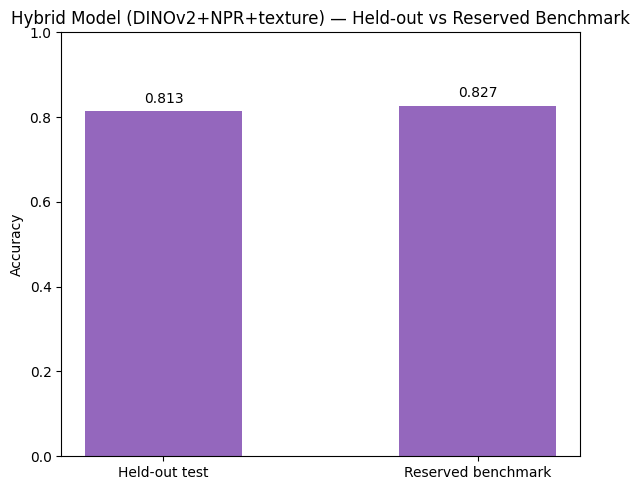

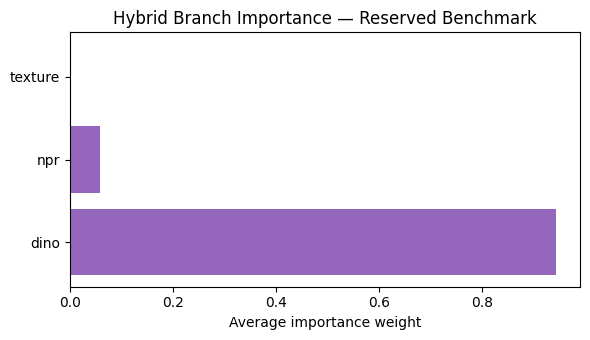

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ==========================================
# CELL 9: Evaluation — hybrid model on held-out
# test_df AND the reserved validation set
# ==========================================
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

def get_hybrid_confidence(pil_img):
    with torch.no_grad():
        logits, weights = hybrid_forward([pil_img])
        prob = torch.sigmoid(logits).item()
    return prob, weights.squeeze(0).cpu().numpy()

def evaluate_set(name, df, sample_n=300):
    df_sample = df.sample(n=min(sample_n, len(df)), random_state=42)
    h_preds, labels, h_weights = [], [], []
    for _, row in df_sample.iterrows():
        img = Image.open(row["image_path"]).convert("RGB")
        p, w = get_hybrid_confidence(img)
        h_preds.append(p); h_weights.append(w)
        labels.append(1 if row["label"] == "fake" else 0)

    preds_arr, labels_arr = np.array(h_preds), np.array(labels)
    bp = (preds_arr > 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels_arr, bp, labels=[0, 1]).ravel()
    results = {
        "accuracy": accuracy_score(labels_arr, bp),
        "auroc": roc_auc_score(labels_arr, preds_arr) if len(set(labels_arr)) > 1 else float("nan"),
        "f1": f1_score(labels_arr, bp),
        "fpr": fp / (fp + tn) if (fp + tn) > 0 else float("nan"),
        "fnr": fn / (fn + tp) if (fn + tp) > 0 else float("nan"),
    }
    print(f"\n=== {name} ===")
    print(pd.Series(results))
    return results, np.array(h_weights)

test_results, _ = evaluate_set("Held-out test set", test_df)
reserved_results, reserved_weights = evaluate_set("RESERVED VALIDATION SET (COCO val2017 + DALL-E Advanced)", reserved_meta)

# --- Visual: hybrid accuracy across both eval sets ---
fig, ax = plt.subplots(figsize=(6, 5))
sets = ["Held-out test", "Reserved benchmark"]
hybrid_acc = [test_results["accuracy"], reserved_results["accuracy"]]
ax.bar(sets, hybrid_acc, width=0.5, color="tab:purple")
ax.set_ylabel("Accuracy"); ax.set_ylim(0, 1)
ax.set_title("Hybrid Model (DINOv2+NPR+texture) — Held-out vs Reserved Benchmark")
for i, v in enumerate(hybrid_acc):
    ax.text(i, v + 0.02, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.savefig(f"{DATA_DIR}/hybrid_accuracy.png", dpi=150)
plt.show()

# --- Visual: hybrid branch importance on the reserved benchmark ---
avg_weights = reserved_weights.mean(axis=0)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.barh(BRANCH_ORDER, avg_weights, color="tab:purple")
ax.set_xlabel("Average importance weight")
ax.set_title("Hybrid Branch Importance — Reserved Benchmark")
plt.tight_layout()
plt.savefig(f"{DATA_DIR}/branch_importance.png", dpi=150)
plt.show()

files.download(f"{DATA_DIR}/hybrid_accuracy.png")
files.download(f"{DATA_DIR}/branch_importance.png")

In [ ]:
# Overwrite predict.py
%%writefile predict.py
import os, glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from PIL import Image
import skimage.feature as skf

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DINO_EMBED_DIM = 384

dino_preprocess = T.Compose([
    T.Resize((224, 224)), T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

IMAGE_EXTENSIONS = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp")

def find_images(directory):
    paths = []
    for ext in IMAGE_EXTENSIONS:
        paths.extend(glob.glob(os.path.join(directory, "**", ext), recursive=True))
    return sorted(paths)

class ResidualEncoder(nn.Module):
    def __init__(self, out_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 8, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(8, 16, 3, stride=2, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(16, out_dim),
        )
    def forward(self, x):
        return self.net(x)

class ImportanceWeightedFusion(nn.Module):
    def __init__(self, branch_dims, common_dim=64):
        super().__init__()
        self.projections = nn.ModuleList([nn.Linear(d, common_dim) for d in branch_dims])
        self.gate = nn.Linear(common_dim, 1)
        self.classifier = nn.Sequential(nn.Linear(common_dim, 32), nn.ReLU(), nn.Linear(32, 1))
    def forward(self, branch_feats):
        projected = [proj(f) for proj, f in zip(self.projections, branch_feats)]
        stacked = torch.stack(projected, dim=1)
        weights = F.softmax(self.gate(stacked).squeeze(-1), dim=1)
        fused = (stacked * weights.unsqueeze(-1)).sum(dim=1)
        return self.classifier(fused).squeeze(-1), weights

def images_to_raw_batch(pil_imgs, size=224):
    arrs = [np.array(img.resize((size, size))).astype(np.float32) / 255.0 for img in pil_imgs]
    return torch.tensor(np.stack(arrs)).permute(0, 3, 1, 2).to(DEVICE)

def compute_npr_residual_batch(raw_batch, scale=0.5):
    down = F.interpolate(raw_batch, scale_factor=scale, mode="bilinear", align_corners=False)
    up = F.interpolate(down, size=raw_batch.shape[-2:], mode="bilinear", align_corners=False)
    return raw_batch - up

def extract_texture_features(pil_img):
    gray = np.array(pil_img.convert("L").resize((128, 128)))
    lbp = skf.local_binary_pattern(gray, P=8, R=1, method="uniform")
    lbp_hist, _ = np.histogram(lbp, bins=10, range=(0, 10), density=True)
    glcm = skf.graycomatrix(gray, distances=[1, 3], angles=[0, np.pi / 2], symmetric=True, normed=True)
    glcm_feats = np.concatenate([skf.graycoprops(glcm, p).flatten()
                                  for p in ["contrast", "homogeneity", "energy", "correlation"]])
    return np.concatenate([lbp_hist, glcm_feats]).astype(np.float32)

def load_models(checkpoint_path):
    dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14').to(DEVICE)
    dinov2.eval()
    for p in dinov2.parameters():
        p.requires_grad = False

    residual_encoder = ResidualEncoder(out_dim=32).to(DEVICE)
    texture_proj = nn.Linear(26, 32).to(DEVICE)
    fusion_head = ImportanceWeightedFusion(branch_dims=[DINO_EMBED_DIM, 32, 32], common_dim=64).to(DEVICE)

    ckpt = torch.load(checkpoint_path, map_location=DEVICE)
    residual_encoder.load_state_dict(ckpt["residual_encoder_state"])
    texture_proj.load_state_dict(ckpt["texture_proj_state"])
    fusion_head.load_state_dict(ckpt["fusion_head_state"])
    residual_encoder.eval(); texture_proj.eval(); fusion_head.eval()

    return {"dinov2": dinov2, "residual_encoder": residual_encoder,
            "texture_proj": texture_proj, "fusion_head": fusion_head}

def predict_image(pil_img, models):
    pil_img = pil_img.convert("RGB")
    dino_batch = dino_preprocess(pil_img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        dino_feats = models["dinov2"](dino_batch)

        raw_batch = images_to_raw_batch([pil_img])
        residuals = compute_npr_residual_batch(raw_batch)
        npr_feats = models["residual_encoder"](residuals)

        tex_vec = torch.tensor(extract_texture_features(pil_img)).to(DEVICE)
        tex_feats = models["texture_proj"](tex_vec).unsqueeze(0)

        logits, _ = models["fusion_head"]([dino_feats, npr_feats, tex_feats])
        prob_fake = torch.sigmoid(logits).item()

    return prob_fake

def main():
    import argparse
    import json

    parser = argparse.ArgumentParser(description="Score a directory of images for AIGC likelihood.")
    parser.add_argument("image_dir", help="Directory of images to score (searched recursively).")
    parser.add_argument("--checkpoint", default="hybrid_checkpoint.pt",
                         help="Path to the trained hybrid_checkpoint.pt")
    parser.add_argument("--output", default="predictions.json",
                         help="Path to write the output JSON file")
    args = parser.parse_args()

    print(f"Loading model from {args.checkpoint}...")
    models = load_models(args.checkpoint)

    image_paths = find_images(args.image_dir)
    print(f"Found {len(image_paths)} images in {args.image_dir}")

    results = []
    for path in image_paths:
        try:
            img = Image.open(path)
            pred = predict_image(img, models)
            results.append({"image_path": path, "pred": round(pred, 4)})
        except Exception as e:
            print(f"Skipping {path} (unreadable): {e}")

    with open(args.output, "w") as f:
        json.dump(results, f, indent=2)
    print(f"Wrote {len(results)} predictions to {args.output}")


if __name__ == "__main__":
    main()

Overwriting predict.py


In [ ]:
!python predict.py /content/data/self_transformed --checkpoint /content/data/hybrid_checkpoint.pt --output /content/data/predictions.json

Loading model from /content/data/hybrid_checkpoint.pt...
Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")
Found 0 images in /content/data/self_transformed
Wrote 0 predictions to /content/data/predictions.json


In [ ]:
# ==========================================
# Cell 11: Produces the clean-vs-transformed comparison
# table for the Robustness Evaluation Summary
# ==========================================
import io
import numpy as np
import pandas as pd
from PIL import Image, ImageFilter
from sklearn.metrics import accuracy_score, roc_auc_score

def apply_jpeg(img, q):
    buf = io.BytesIO(); img.save(buf, format="JPEG", quality=q); buf.seek(0)
    return Image.open(buf).convert("RGB")

def apply_blur(img, sigma):
    return img.filter(ImageFilter.GaussianBlur(radius=sigma))

def apply_resize(img, scale):
    w, h = img.size
    small = img.resize((max(1, int(w*scale)), max(1, int(h*scale))), Image.BILINEAR)
    return small.resize((w, h), Image.BILINEAR)

def apply_noise(img, sigma):
    arr = np.array(img).astype(np.float32) / 255.0
    arr = np.clip(arr + np.random.normal(0, sigma, arr.shape), 0, 1) * 255
    return Image.fromarray(arr.astype(np.uint8))

def apply_crop(img, frac=0.8):
    w, h = img.size
    nw, nh = int(w*frac), int(h*frac)
    left, top = (w-nw)//2, (h-nh)//2
    return img.crop((left, top, left+nw, top+nh)).resize((w, h), Image.BILINEAR)

CONDITIONS = {
    "Clean": lambda img: img,
    "JPEG (q=30)": lambda img: apply_jpeg(img, 30),
    "Blur (sigma=2.0)": lambda img: apply_blur(img, 2.0),
    "Resize (0.25x)": lambda img: apply_resize(img, 0.25),
    "Noise (sigma=0.10)": lambda img: apply_noise(img, 0.10),
    "Center crop (80%)": lambda img: apply_crop(img, 0.8),
}

def get_hybrid_confidence(pil_img):
    with torch.no_grad():
        logits, _ = hybrid_forward([pil_img])
        return torch.sigmoid(logits).item()

def evaluate_condition(df, transform_fn, sample_n=150):
    df_sample = df.sample(n=min(sample_n, len(df)), random_state=42)
    preds, labels = [], []
    for _, row in df_sample.iterrows():
        img = Image.open(row["image_path"]).convert("RGB")
        img = transform_fn(img)
        preds.append(get_hybrid_confidence(img))
        labels.append(1 if row["label"] == "fake" else 0)
    preds, labels = np.array(preds), np.array(labels)
    binary_preds = (preds > 0.5).astype(int)
    return {
        "accuracy": accuracy_score(labels, binary_preds),
        "auroc": roc_auc_score(labels, preds) if len(set(labels)) > 1 else float("nan"),
    }

rows = []
for name, fn in CONDITIONS.items():
    print(f"Evaluating: {name}...")
    metrics = evaluate_condition(test_df, fn)
    rows.append({"Condition": name, "Accuracy": f"{metrics['accuracy']*100:.1f}%",
                 "AUROC": f"{metrics['auroc']*100:.1f}%"})
    print(f"  {rows[-1]}")

robustness_table = pd.DataFrame(rows)
print("\n" + robustness_table.to_markdown(index=False))
robustness_table.to_csv(f"{DATA_DIR}/robustness_table.csv", index=False)

from google.colab import files
files.download(f"{DATA_DIR}/robustness_table.csv")

Evaluating: Clean...
  {'Condition': 'Clean', 'Accuracy': '86.0%', 'AUROC': '91.9%'}
Evaluating: JPEG (q=30)...
  {'Condition': 'JPEG (q=30)', 'Accuracy': '84.7%', 'AUROC': '89.8%'}
Evaluating: Blur (sigma=2.0)...
  {'Condition': 'Blur (sigma=2.0)', 'Accuracy': '80.0%', 'AUROC': '88.2%'}
Evaluating: Resize (0.25x)...
  {'Condition': 'Resize (0.25x)', 'Accuracy': '75.3%', 'AUROC': '86.8%'}
Evaluating: Noise (sigma=0.10)...
  {'Condition': 'Noise (sigma=0.10)', 'Accuracy': '80.0%', 'AUROC': '87.6%'}
Evaluating: Center crop (80%)...
  {'Condition': 'Center crop (80%)', 'Accuracy': '84.0%', 'AUROC': '90.5%'}

| Condition          | Accuracy   | AUROC   |
|:-------------------|:-----------|:--------|
| Clean              | 86.0%      | 91.9%   |
| JPEG (q=30)        | 84.7%      | 89.8%   |
| Blur (sigma=2.0)   | 80.0%      | 88.2%   |
| Resize (0.25x)     | 75.3%      | 86.8%   |
| Noise (sigma=0.10) | 80.0%      | 87.6%   |
| Center crop (80%)  | 84.0%      | 90.5%   |


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ==========================================
# Cell 12: Pulls the most-confidently-wrong predictions
# for the Error Analysis Note
# ==========================================
import numpy as np
import pandas as pd

def collect_predictions(df, sample_n=300):
    df_sample = df.sample(n=min(sample_n, len(df)), random_state=42).reset_index(drop=True)
    preds = []
    for _, row in df_sample.iterrows():
        img = Image.open(row["image_path"]).convert("RGB")
        preds.append(get_hybrid_confidence(img))
    df_sample["pred"] = preds
    df_sample["true_label"] = df_sample["label"]
    df_sample["binary_pred"] = (df_sample["pred"] > 0.5).map({True: "fake", False: "real"})
    return df_sample

results_df = collect_predictions(test_df)

false_positives = results_df[
    (results_df["true_label"] == "real") & (results_df["binary_pred"] == "fake")
].sort_values("pred", ascending=False).head(5)

false_negatives = results_df[
    (results_df["true_label"] == "fake") & (results_df["binary_pred"] == "real")
].sort_values("pred", ascending=True).head(5)

print("=== TOP FALSE POSITIVES (real images flagged as fake) ===")
print(false_positives[["image_path", "source_dataset", "pred"]].to_string(index=False))

print("\n=== TOP FALSE NEGATIVES (fake images flagged as real) ===")
print(false_negatives[["image_path", "source_dataset", "pred"]].to_string(index=False))

# Pattern check: are errors concentrated in one source dataset?
print("\n=== Error rate by source dataset ===")
results_df["correct"] = results_df["true_label"] == results_df["binary_pred"]
print(results_df.groupby("source_dataset")["correct"].agg(["mean", "count"]))

false_positives.to_csv(f"{DATA_DIR}/false_positives.csv", index=False)
false_negatives.to_csv(f"{DATA_DIR}/false_negatives.csv", index=False)
from google.colab import files
files.download(f"{DATA_DIR}/false_positives.csv")
files.download(f"{DATA_DIR}/false_negatives.csv")

=== TOP FALSE POSITIVES (real images flagged as fake) ===
                                                                                                                                                                image_path       source_dataset     pred
/kaggle/input/aigc-detection-dataset/transformed_data/transformed_data/test/real/real_01516__v3__center_crop-80_color-minus20_blur-sigma_0.5_noise-sigma_0.05_jpeg-q50.png self_transformed_set 0.985852
                                                                                                                                        /content/data/sid_set/real_203.jpg              sid_set 0.953394
                                                                                       /kaggle/input/cifake-real-and-ai-generated-synthetic-images/train/REAL/1358 (8).jpg               cifake 0.936648
                                                                                           /kaggle/input/cifake-real-and-ai-generated-synt

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ==========================================
# CELL 13: Interactive Demo — Hybrid Model
# ==========================================
import time
import io
import cv2
import gradio as gr
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance, ImageFilter


# ---------- Startup check: confirm everything this demo needs exists ----------
_REQUIRED = ["hybrid_forward", "dinov2", "dino_preprocess", "residual_encoder",
             "texture_proj", "extract_texture_features", "BRANCH_ORDER", "DEVICE"]
_missing = [name for name in _REQUIRED if name not in globals()]
if _missing:
    raise RuntimeError(
        f"Cannot start Katsu demo — these are not defined in this session: {_missing}. "
        f"Run the data pipeline + model definition + training cells above first, "
        f"in the same notebook session, before running this cell."
    )
print("All required model objects found — proceeding.")


# ---------- Real spatial signal, self-contained ----------

def get_dino_spatial_heatmap(pil_img, target_size):
    """DINOv2 hub models normally expose get_intermediate_layers(...,
    reshape=True) for real per-patch spatial features. Falls back to a
    uniform map with a clear print if that method isn't available on
    this particular loaded model, rather than crashing the whole demo."""
    x = dino_preprocess(pil_img).unsqueeze(0).to(DEVICE)
    try:
        with torch.no_grad():
            feats = dinov2.get_intermediate_layers(x, n=1, reshape=True)[0]  # (1, C, h, w)
        act = feats.squeeze(0).mean(dim=0).cpu().numpy()
    except (AttributeError, TypeError) as e:
        print(f"DINOv2 spatial extraction unavailable ({e}); using uniform fallback map.")
        act = np.ones((16, 16), dtype=np.float32) * 0.5
    act = np.maximum(act, 0)
    if act.max() > 0:
        act = act / act.max()
    return cv2.resize(act, target_size)

def get_npr_spatial_heatmap(pil_img, target_size, scale=0.5):
    """Self-contained NPR residual computation — does not assume
    images_to_raw_batch / compute_npr_residual_batch exist, since
    different pipeline versions used different helper names."""
    arr = np.array(pil_img.resize((224, 224))).astype(np.float32) / 255.0
    t = torch.tensor(arr).permute(2, 0, 1).unsqueeze(0).to(DEVICE)
    down = F.interpolate(t, scale_factor=scale, mode="bilinear", align_corners=False)
    up = F.interpolate(down, size=(224, 224), mode="bilinear", align_corners=False)
    residual = (t - up).squeeze(0)
    act = residual.abs().mean(dim=0).cpu().numpy()  # (224, 224)
    if act.max() > 0:
        act = act / act.max()
    return cv2.resize(act, target_size)

def overlay_heatmap(image_np, heatmap_2d, alpha=0.45):
    h, w, _ = image_np.shape
    if heatmap_2d.shape != (h, w):
        heatmap_2d = cv2.resize(heatmap_2d, (w, h))
    saliency_uint8 = np.uint8(255 * heatmap_2d)
    colored = cv2.applyColorMap(saliency_uint8, cv2.COLORMAP_JET)
    colored_rgb = cv2.cvtColor(colored, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(image_np, 1 - alpha, colored_rgb, alpha, 0)

    active_mask = saliency_uint8 > 120
    active_ratio = (np.sum(active_mask) / (h * w)) * 100
    if np.any(active_mask):
        peak_y, peak_x = np.unravel_index(np.argmax(saliency_uint8), (h, w))
        v = "top" if peak_y < h / 3 else ("bottom" if peak_y > 2 * h / 3 else "center")
        hpos = "left" if peak_x < w / 3 else ("right" if peak_x > 2 * w / 3 else "center")
        loc_str = f"{v}-{hpos}" if v != hpos else v
    else:
        loc_str = "diffuse/broad region"
    return overlay, active_ratio, loc_str

def texture_feature_bar(pil_img):
    """Honest alternative to a fake heatmap: LBP/GLCM features are
    already spatially pooled to a flat 26-dim vector by this point,
    so there's no real spatial location to show. Show the actual
    feature values instead of fabricating a spatial map."""
    feats = extract_texture_features(pil_img)  # 26-dim: 10 LBP bins + 16 GLCM props
    labels = [f"LBP_{i}" for i in range(10)] + [f"GLCM_{i}" for i in range(16)]
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.bar(range(len(feats)), feats, color="teal")
    ax.set_xticks(range(len(feats)))
    ax.set_xticklabels(labels, rotation=90, fontsize=6)
    ax.set_title("Texture branch — raw LBP/GLCM feature values")
    plt.tight_layout()
    plt.close(fig)  # prevent Colab from auto-displaying this inline — Gradio
                     # renders the returned Figure object on its own, doesn't
                     # need pyplot to keep it "open"
    return fig


# ---------- Transform application ----------

def apply_selected_transforms(pil_img, selected_transforms):
    if not selected_transforms or pil_img is None:
        return pil_img
    transformed = pil_img.copy()
    if "Gaussian Blur" in selected_transforms:
        transformed = transformed.filter(ImageFilter.GaussianBlur(radius=2))
    if "Add Gaussian Noise" in selected_transforms:
        np_img = np.array(transformed).astype(np.float32)
        noise = np.random.normal(0, 12, np_img.shape)
        transformed = Image.fromarray(np.clip(np_img + noise, 0, 255).astype(np.uint8))
    if "JPEG Compression" in selected_transforms:
        buf = io.BytesIO()
        transformed.save(buf, format="JPEG", quality=35)
        buf.seek(0)
        transformed = Image.open(buf).convert("RGB")
    if "Brightness Adjustment" in selected_transforms:
        transformed = ImageEnhance.Brightness(transformed).enhance(1.25)
    return transformed


# ---------- Inference, using the real trained hybrid model ----------

def run_hybrid_inference(pil_img, selected_transforms):
    if pil_img is None:
        return (None, "No image uploaded", 0.0, "0 ms", {},
                None, None, None)

    start_time = time.time()
    processed_img = apply_selected_transforms(pil_img, selected_transforms).convert("RGB")
    img_np = np.array(processed_img)
    target_size = (processed_img.width, processed_img.height)

    try:
        with torch.no_grad():
            logits, weights = hybrid_forward([processed_img])
        prob = torch.sigmoid(logits).item()
        b_weights = weights.detach().cpu().numpy().squeeze(0)
    except Exception as e:
        return (processed_img, f"Inference Error: {e}", 0.0, "0 ms", {}, None, None, None)

    latency_ms = f"{int((time.time() - start_time) * 1000)} ms"
    weight_dict = {name: float(w) for name, w in zip(BRANCH_ORDER, b_weights)}
    verdict_label = f"Classified as {'Fake' if prob > 0.5 else 'Real'} — {prob*100:.1f}% confidence AI-generated"

    dino_map = get_dino_spatial_heatmap(processed_img, target_size)
    dino_overlay, dino_ratio, dino_loc = overlay_heatmap(img_np, dino_map)

    npr_map = get_npr_spatial_heatmap(processed_img, target_size)
    npr_overlay, npr_ratio, npr_loc = overlay_heatmap(img_np, npr_map)

    texture_fig = texture_feature_bar(processed_img)

    dino_exp = f"DINOv2 branch: peak activation in {dino_loc} region, covering {dino_ratio:.1f}% of the frame."
    npr_exp = f"NPR branch: highest reconstruction residual in {npr_loc} region, covering {npr_ratio:.1f}% of the frame."

    return (processed_img, verdict_label, float(prob), latency_ms, weight_dict,
            dino_overlay, dino_exp, npr_overlay, npr_exp, texture_fig)


# ---------- Gradio UI ----------

theme = gr.themes.Soft(
    primary_hue="violet",
    secondary_hue="fuchsia",
    neutral_hue="slate",
).set(
    button_primary_background_fill="*primary_500",
    button_primary_background_fill_hover="*primary_600",
    block_title_text_color="*primary_600",
)

with gr.Blocks(title="Katsu — AIGC Detection") as demo:
    gr.Markdown(
        """
        <div style="text-align:center;">
        <h1 style="color:#7c3aed; margin-bottom:0;">🔎 Katsu</h1>
        <p style="color:#6b7280; margin-top:4px;">Hybrid AIGC Detector — Forensic Audit Dashboard</p>
        </div>
        """
    )

    with gr.Row():
        with gr.Column(scale=1):
            input_image = gr.Image(type="pil", label="Upload Target Image")
            transform_toggles = gr.CheckboxGroup(
                choices=["Gaussian Blur", "Add Gaussian Noise", "JPEG Compression", "Brightness Adjustment"],
                label="Apply Transformations",
            )
            with gr.Row():
                clear_btn = gr.Button("Reset", variant="secondary")
                submit_btn = gr.Button("Analyze Image", variant="primary")
            latency_output = gr.Textbox(label="Inference Latency", value="0 ms", interactive=False)

        with gr.Column(scale=2):
            transformed_preview = gr.Image(type="pil", label="Model Input Preview", interactive=False)
            verdict_output = gr.Textbox(label="Classification Decision", interactive=False)
            prob_output = gr.Slider(label="Fake Probability", minimum=0.0, maximum=1.0, interactive=False)
            weights_output = gr.Label(label="Branch Weight Contribution")

    gr.Markdown("---")
    gr.Markdown(
        "### Spatial Attribution — DINOv2 and NPR are genuinely spatial; "
        "texture is shown as raw features, not a fabricated heatmap."
    )

    with gr.Row():
        with gr.Column():
            cam_dino = gr.Image(label="DINOv2 — spatial attention")
            exp_dino = gr.Textbox(label="DINOv2 analysis", lines=2, interactive=False)
        with gr.Column():
            cam_npr = gr.Image(label="NPR — residual magnitude")
            exp_npr = gr.Textbox(label="NPR analysis", lines=2, interactive=False)
        with gr.Column():
            cam_texture = gr.Plot(label="Texture — LBP/GLCM feature values")

    submit_btn.click(
        fn=run_hybrid_inference,
        inputs=[input_image, transform_toggles],
        outputs=[transformed_preview, verdict_output, prob_output, latency_output,
                 weights_output, cam_dino, exp_dino, cam_npr, exp_npr, cam_texture],
    )

    clear_btn.click(
        fn=lambda: (None, None, "", 0.0, "0 ms", {}, None, "", None, "", None),
        inputs=None,
        outputs=[input_image, transformed_preview, verdict_output, prob_output, latency_output,
                 weights_output, cam_dino, exp_dino, cam_npr, exp_npr, cam_texture],
    )

# ---------- Self-test before launch: catches errors here, in the cell
# output, instead of discovering them later inside the Gradio UI ----------
print("\nRunning self-test on a synthetic image before launching...")
try:
    _test_img = Image.fromarray((np.random.rand(224, 224, 3) * 255).astype(np.uint8))
    _result = run_hybrid_inference(_test_img, [])
    if "Error" in str(_result[1]):
        raise RuntimeError(_result[1])
    print(f"Self-test passed — verdict: {_result[1]}, latency: {_result[3]}")
except Exception as e:
    raise RuntimeError(
        f"Self-test failed before launch: {e}\n"
        f"Fix this error above before trying to use the UI — the UI will "
        f"show the same failure on every image otherwise."
    )

demo.launch(share=True, theme=theme)

All required model objects found — proceeding.

Running self-test on a synthetic image before launching...
Self-test passed — verdict: Classified as Fake — 79.1% confidence AI-generated, latency: 932 ms
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f024fd94d85b99269c.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
